In [2]:
using Pkg
Pkg.add("DataFrames")
Pkg.add("Indicators")
Pkg.add("Interact")
Pkg.add("Statistics")
Pkg.add("Pipe")
Pkg.add("CSV")
Pkg.add("Plots")
Pkg.add("Interact")
Pkg.add("Colors")
Pkg.add("JSON")
Pkg.add("Query")


   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
Precompiling project...
  ✓ ArrayInterface → ArrayInterfaceChainRulesExt
  1 dependency successfully precompiled in 2 seconds. 337 already precompiled.
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.to

In [3]:
# using Pipe
using DataFrames
# using StatsPlots
using CSV
# using RollingFunctions
using Query
# using GLMakie

using JSON
using DataFrames
using Dates
using Colors
# using ColorSchemes
using Indicators

import Colors
using Plots
using Interact
using Statistics
# using JuliaDB
# using Wavelets,WaveletsExt
# using LinearAlgebra
# import Pkg; Pkg.add("ShiftedArrays")
# using ShiftedArrays
# include("utils.jl")

In [5]:
json_data_folder = "/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/binance"
pair = "BTC_USDT"
tframe = "1d"
# json_filename = "ETH_USDT-1m.json"
json_filepath = "$json_data_folder/$pair-$tframe.json"
f = open(json_filepath, "r")
json_data = JSON.parse(f)
close(f)

In [6]:
 fname = "/media/mu6mula/Data/Quant/pk-crypto-tools/lppls-master/lppls/data/nasdaq_dotcom.csv"
 odf = DataFrame(CSV.File(fname))

Row,Date,Open,High,Low,Close,Adj Close,Volume
,Date,Float64,Float64,Float64,Float64,Float64,Int64
1,1994-01-03,774.11,777.29,768.41,770.76,770.76,253020000
2,1994-01-04,771.43,774.78,771.02,774.28,774.28,298600000
3,1994-01-05,775.23,778.21,773.69,778.05,778.05,349880000
4,1994-01-06,780.36,781.21,778.25,780.41,780.41,349210000
5,1994-01-07,779.29,783.39,778.2,782.94,782.94,330060000
6,1994-01-10,783.05,787.49,782.92,786.69,786.69,313350000
7,1994-01-11,785.93,787.32,784.34,785.52,785.52,321930000
8,1994-01-12,788.2,788.43,782.68,786.87,786.87,322540000
9,1994-01-13,784.36,787.85,783.97,787.81,787.81,290110000


In [ ]:
# odf = DataFrame(unix_time = Int64[], open=Float64[], high=Float64[], low=Float64[], close=Float64[], volume=Float64[])
# for r in json_data push!(odf, r) end
# odf.unix_time .= odf.unix_time ./1000
# # dfa.time .= unix2datetime.(dfa.unix_time)

# # insertcols!(odf, :time => unix2datetime.(odf.unix_time))
# # nrow(odf)
# odf

In [ ]:
# start_date = DateTime(2021, 3, 1)
# end_date = DateTime(2024, 6, 9)
# vdf = dfa[(dfa.time .>= start_date) .& (dfa.time .<= end_date) , :]
# ut, tt, hh, ll, cc = vdf.unix_time, vdf.time, vdf.high, vdf.low, vdf.close
# # h14max = [fill(vdf[1,:high],8-1)...,rollmax(vdf.high, 8)...]
# #  length(h14max), length(vdf.close)
# # hlc = [hh ll cc]
# length(tt)

In [1]:
# data

UndefVarError: UndefVarError: `data` not defined

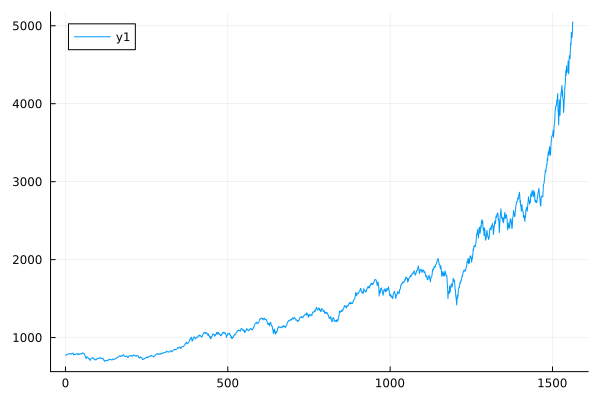

In [7]:
c = odf[:,6]
f1 = plot(c)
# plot!(put,ema_1[rng], label="ema1",lw=0.8)

In [ ]:
all([1,2,3] .> [0,1,1])

In [ ]:
function backtest(sl_slider, tp_slider, negated_slider, cooloff_slider, ema_1, ema_1_ch, ema_2, ema_2_ch)
#     println("$sl_slider, $lg_thresh_slider, $tp_slider")
    capital = 10000.
    risk_percent = 0.02
    qfee = 0.001
    

    dfo = DataFrame(ut = Int64[], 
            tt = DateTime[],
            order = Symbol[],
            oix = Int64[],
            reason = Symbol[],
            price = Float64[],
#             target = Float64[],
            stop = Float64[],
            qty = Float64[],
            pnl = Float64[],
            capital = Float64[]
        )

    push!(dfo, (ut = ut[1], tt=tt[1], oix =0, order = :long, reason = :toolong, price = 0, stop = 0,
                qty = 0, pnl = 0, capital = capital))


    in_long_pos = false 
    qlsellsig = 1.01
    qstop = 0.01
    in_i = 0
    for i in 300:length(cc)

        ord = last(dfo)
        if !in_long_pos
            if true &&
                (ord.pnl > 0 || i - ord.oix > cooloff_slider) &&
                cc[i-1] < ema_2_ch[i-1] && cc[i] > ema_2_ch[i] 
#                 ema_1[i] < ema_2_ch[i] 
                
#                 stop_price = cc[i] * (1 - sl_slider/100)
                stop_price = minimum(cc[i-30:i])* (1 - sl_slider/100)


#                 stop_price = cc[i] * (1 - sl/100) # * (1-qfee)

                risk_size = capital * risk_percent

                buy_price = cc[i]*(1+qfee)

                risk_price_range = (buy_price - stop_price)
                buyq = risk_size / risk_price_range

#                 target = cc[i] * (1+target_pe/100)  # 2*risk_price_range

                push!(dfo, (ut = ut[i], tt=tt[i], oix=i, order = :long, reason = :enter, price = buy_price, qty = buyq,
                        stop = stop_price, pnl = 0, capital = capital))

                in_long_pos = true
            end
        else
#             sell = false
            if cc[i] > ord.price * (1 + tp_slider/100)
                ord.stop = cc[i]
#             elseif i - ord.oix > negated_slider && all(cc[i-15:i] .< ema_2[i-15:i]) && ord.stop < ord.price
#                 ord.stop = ema_2[i]
#             elseif cc[i]
#             elseif cc[i-1] < ema_2[i-1] && cc[i] > ema_2[i] && ord.stop < ord.price
#                 ord.stop = ord.price
#             elseif minimum(cc[i-30:i]) > ord.stop
#                 ord
#             elseif minimum(cc[i-26*2]) < minimum(cc[i-26*1]) && 
#                 cc[i] > 1.005 * minimum(cc[i-26*2]) &&
#                 ord.stop < minimum(cc[i-26*2])
                
#                 ord.stop = minimum(cc[i-26*2])
                
            end
            
            if cc[i] <= ord.stop
                sell_price = cc[i]*(1-qfee)
                profit_loss = ord.qty * (sell_price - ord.price)
                capital = capital + profit_loss

                push!(dfo, (ut = ut[i], tt=tt[i], oix=i, order = :long, reason = :exit, price = sell_price, stop = 0, 
                         qty = ord.qty, pnl = profit_loss, capital = capital))

                in_long_pos = false
            end
           

        end
    #     println(capital)

    end
    CSV.write("trades.csv", dfo)
    dfo
end

In [ ]:
ar_len = length(cc)
plot_box = Observable{Any}(dom"div"())
res_box = Observable{Any}(dom"div"())
window_size = 60 * 8 * 3 * 7
num_windows = Int64(trunc(ar_len/window_size*1))
window_no_slider = slider(1:num_windows; label="start", default=7)
window_start = Interact.@map max(1, Int(&window_no_slider * window_size / 1))
window_end = Interact.@map min(ar_len, &window_start+window_size-1)
rng = Interact.@map &window_start: &window_end
put = Interact.@map ut[&rng]
wtt = Interact.@map tt[&rng]

ema_1_slider = slider(0:10:400; label="ema1", default=50)
ema_1 = Interact.@map ema(cc, n=&ema_1_slider)
ema_1_x_slider = slider(0:5:240; label="ema1X", default=0)
ema_1_y_slider = slider(-5:0.1:5; label="ema1Y", default=0)
ema_1_trans = Interact.@map circshift((&ema_1 .* (1 + &ema_1_y_slider/100)), &ema_1_x_slider)
ema_1_ch_slider = slider(-5:0.1:1; label="ema1ch", default=-1)
ema_1_ch = Interact.@map &ema_1_trans .* (1 + &ema_1_ch_slider / 100)

ema_2_slider = slider(0:10:400; label="ema2", default=50)
ema_2 = Interact.@map ema(cc, n=&ema_2_slider)
ema_2_x_slider = slider(0:5:240; label="ema2X", default=0)
ema_2_y_slider = slider(-5:0.1:5; label="ema2Y", default=0)
ema_2_trans = Interact.@map circshift((&ema_2 .* (1 + &ema_2_y_slider/100)), &ema_2_x_slider)
ema_2_ch_slider = slider(-5:0.1:1; label="ema2ch", default=-1)
ema_2_ch = Interact.@map &ema_2_trans .* (1 + &ema_2_ch_slider / 100)

negated_slider = slider(0:600; label="neg", default=-1)
cooloff_slider = slider(0:5:600; label="cool", default=-1)
# log_ema_slider = slider(0:100; label="emalog", default=7)
# log_val = Interact.@map log.(cc ./ &ema_1) .* 1000
# log_ema = Interact.@map ema(&log_val, n=&log_ema_slider)
# lg_thresh_slider = slider(-2:0.1:5; label="tsh", default=0.1)

sl_slider = slider(0:0.2:5; label="sl", default=0.1)
tp_slider = slider(0:0.1:5; label="tp", default=1)
# look_back_slider = slider(0:5:240; label="lb", default=10)


dfo = Interact.@map backtest(&sl_slider, &tp_slider, &negated_slider, &cooloff_slider, &ema_1_trans, &ema_1_ch, &ema_2_trans, &ema_2_ch)

wdfo = Interact.@map filter(row -> (row.ut >= ut[&window_start] && row.ut <= ut[&window_end]), &dfo, view=false)

# res_capital = Interact.@map trunc(last(&wdfo).capital)

buys = Interact.@map filter(row -> row.reason == :enter, &wdfo)
losses = Interact.@map filter(row -> row.reason == :exit && row.pnl < 0, &wdfo)
profits = Interact.@map filter(row -> row.reason == :exit && row.pnl > 0, &wdfo)
no_losses = Interact.@map nrow(&losses)
no_profits = Interact.@map nrow(&profits)
tot_losses = Interact.@map Int(trunc(sum((&losses).pnl)))
tot_profits = Interact.@map Int(trunc(sum((&profits).pnl)))


wbuys = Interact.@map filter(row -> row.reason == :enter, &wdfo)
wlosses = Interact.@map filter(row -> row.reason == :exit && row.pnl < 0, &wdfo)
wprofits = Interact.@map filter(row -> row.reason == :exit && row.pnl > 0, &wdfo)

# , buys, profits, losses
function draw_it_all(rng, ema_1, ema_1_ch, ema_2, ema_2_ch, buys, profits, losses)
    put = ut[rng]   
    
    f1 = plot(put, cc[rng], size=(1200,500))
    plot!(put,ema_1[rng], label="ema1",lw=0.8)
    plot!(put,ema_2[rng], label="ema2",lw=0.8)
    
#     plot!(put,ema_1[rng], fillrange=ema_1_ch[rng], fillalpha=0.15, label="ch1",lw=0)
    plot!(put,ema_2[rng], fillrange=ema_2_ch[rng], fillalpha=0.15, label="ch2",lw=0)
    
    
    nrow(buys) > 0 && vline!(buys.ut,lw=0.5, color=:blue)
    nrow(profits) > 0 && vline!(profits.ut,lw=0.5, color=:green)
    nrow(losses) > 0 && vline!(losses.ut,lw=0.5, color=:red)
    
#     f2 = plot(put, log_val[rng])
#     plot!(put, log_ema[rng])
#     hline!(-10,lw=1)
    
#     plt = plot(f1, f2, layout=@layout[a{0.6h}; b{0.25h};], size=(1400,500))
    dom"div"(vbox(f1))
end
# , wbuys, wprofits, wlosses
map!(draw_it_all, plot_box, rng, ema_1_trans, ema_1_ch, ema_2_trans, ema_2_ch, wbuys, wprofits, wlosses)

ema_1_slider[]=90
ema_1_ch_slider[]=-0.6
ema_1_x_slider[] = 0
ema_1_y_slider[] = -2.30

ema_2_slider[]=100
ema_2_ch_slider[]=-0.6
ema_2_x_slider[] = 0
ema_2_y_slider[] = 0

negated_slider[] = 222
cooloff_slider[] = 310
sl_slider[] = 3.4
tp_slider[]=3.3
# lg_thresh_slider[] = 1
# look_back_slider[] = 5
# dff = dateformat"Y-m-d H:M:S"
dff = dateformat"mm/dd"
ui = dom"div"(hbox(
            vbox(ema_1_slider, ema_1_ch_slider, ema_1_x_slider, ema_1_y_slider),
            vbox(ema_2_slider, ema_2_ch_slider, ema_2_x_slider, ema_2_y_slider),
            vbox(sl_slider,tp_slider,negated_slider,cooloff_slider),
#         ,lg_thresh_slider,look_back_slider
#             vbox(log_ema_slider,sl_slider),
            Interact.@map vbox( (&no_losses,&no_profits),
                                    (&tot_losses, &tot_profits),
                                    (&tot_losses + &tot_profits))
        ),
        plot_box,window_no_slider,
        Interact.@map vbox(("$(Dates.format(first(tt),dff))","$(Dates.format(last(tt),dff))"), 
            ("$(Dates.format(first(&wtt),dff))","$(Dates.format(last(&wtt),dff))"))
        )
# using Interact, Blink
# w = Window()
# body!(w, ui);
ui
# 1

In [ ]:
using Dates
dff = dateformat"Y-m-d H:M:S"
Dates.format(now(),dff)

In [ ]:
last(dfo[])